# Statistik-Labor Testat Aufgabe 1
***Hinweise:***
- Bitte überprüfen Sie Ihre Resultate vor der Abgabe Ihre Ergebnisse mit den Teilergebnissen aus der Datei ***Teilergebnisse_xy.txt***. In der Datei bekommen Sie jeweils die ersten beiden Nachkommastellen des Durchschnittsalters.
- Die Unterlagen sind im **pdf-Format** in Moodle hochgeladen abzugeben. Richtige Lösungen werden nicht mehr an Sie zurückgegeben. Eine Abgabe per Email ist nicht möglich.
- Bitte geben Sie Ihrer Abgabedatei einen **sinnvollen Dateinamen**, z.B.: Testat1\_*Nachname*\_*Matrikelnummer*\_v*X*. *(Wobei X für die Abgabeversion 1 bis 3 steht.)*

## ***Aufgabenstellung:***
Sie sollen für die Personalabteilung der NANUAG die Altersverteilung der Beschäftigten analysieren. <br>
In der Datei **sr_aufg_1_xy.txt** im Unterverzeichnis **Endziffer_xy** (*„xy“ steht für die beiden Endziffern Ihrer Matrikelnummer*) finden Sie die dafür erforderlichen Daten. <br>
Diese Datei enthält folgende fünf Felder, die durch Semikolons getrennt sind: Personalnummer, Anrede („Herr“ oder „Frau“), Vorname, Nachname, Geburtsdatum.

## a) Daten einlesen
Lesen Sie die Daten in **Python** bzw. ein **Jupyter Notebook** ein. Speichern Sie sie in einem **Pandas DataFrame** ab.

***Tipp:*** Bitte beachten Sie bei der Abgabe, dass Sie auf keinen Fall die Liste mit den 100 Datensätzen ausgeben! Verwenden Sie dafür zum Beispiel die `dataframe.head()`-Funktion.

In [98]:
import pandas as pd

#ToDo: 1. Ersetzen Sie im Dateinamen xy durch entsprechende Matrikelnummer
#      2. Lassen Sie sich alle Daten anzeigen, um "fehlerhafte" Daten zu erkennen; vor Abgabe bitte nur z.B. die ersten 5

data = pd.read_csv('sr_aufg_1_96.txt', sep=';', 
            encoding='unicode_escape', na_values='.', header = None, 
            names=['ID', 'Anrede', 'Vorname', 'Nachname', 'Geburtsdatum'])
display(data.head())

,ID,Anrede,Vorname,Nachname,Geburtsdatum
0,1,Herr,Konrad,Weiß,28.05.1955
1,2,Frau,Hanna,Glaser,27.08.1956
2,3,Frau,Corinna,Frank,20.09.1965
3,4,Frau,Dagmar,Raabe,25.11.1957
4,5,Herr,David,Becker,07.12.1957


## b) Daten bereinigen
Führen Sie eine Datenbereinigung durch. <br>
Listen Sie in einer Tabelle auf, welche (Daten-)Sätze Sie gelöscht und welche Sätze Sie wie korrigiert haben. 

***Tipp:*** Sie können hierzu die Python Funktionen `dataframe.drop()` und `dataframe.at()` verwenden. <br>
***Beispiellösung:***
[Tabelle mit den gelöschten & korrigierten Daten](https://drive.google.com/uc?id=1z5Gydg1HzoxZLo428862fsgsKyaHKKm9)

In [99]:

# Protokolltabelle für die Bereinigung
bereinigung = []

# 1) Eindeutig korrigierbare Datensätze berichtigen

# ID 029 / Index 28
alter_wert = data.at[28, "Geburtsdatum"]
data.at[28, "Geburtsdatum"] = "27.02.1970"
bereinigung.append([
    data.at[28, "ID"],
    28,
    "korrigiert",
    "Geburtsdatum",
    alter_wert,
    "27.02.1970"
])

# ID 099 / Index 98
alter_vorname = data.at[98, "Vorname"]
alter_nachname = data.at[98, "Nachname"]
alter_geb = data.at[98, "Geburtsdatum"]

data.at[98, "Vorname"] = "Andreas"
data.at[98, "Nachname"] = "Sauer"
data.at[98, "Geburtsdatum"] = "22.09.1943"

bereinigung.append([
    data.at[98, "ID"],
    98,
    "korrigiert",
    "Vorname/Nachname",
    f"Vorname='{alter_vorname}', Nachname='{alter_nachname}', Geburtsdatum='{alter_geb}'",
    "Vorname='Andreas', Nachname='Sauer', Geburtsdatum='22.09.1943'"
])

# 2) Nicht eindeutig rekonstruierbare Datensätze löschen
zu_loeschen = [16, 21, 32, 46, 52, 56, 67, 71, 92, 103]

for idx in zu_loeschen:
    bereinigung.append([
        data.at[idx, "ID"],
        idx,
        "gelöscht",
        "ganzer Datensatz",
        f"{data.at[idx, 'Anrede']}; {data.at[idx, 'Vorname']}; {data.at[idx, 'Nachname']}; {data.at[idx, 'Geburtsdatum']}",
        "nicht eindeutig rekonstruierbar"
    ])

data = data.drop(index=zu_loeschen)

# Bereinigungsprotokoll als Tabelle
bereinigung_df = pd.DataFrame(
    bereinigung,
    columns=["ID", "Index", "Maßnahme", "Feld", "Alter Wert", "Neuer Wert / Begründung"]
)

# Optional: Index neu setzen
data = data.reset_index(drop=True)

# Ausgabe
display(bereinigung_df)
print("Anzahl Datensätze nach Bereinigung:", len(data))

,ID,Index,Maßnahme,Feld,Alter Wert,Neuer Wert / Begründung
0,29,28,korrigiert,Geburtsdatum,am 27. Februar 1970,27.02.1970
1,99,98,korrigiert,Vorname/Nachname,"Vorname='Andreas Sauer', Nachname='22.09.1943'...","Vorname='Andreas', Nachname='Sauer', Geburtsda..."
2,17,16,gelöscht,ganzer Datensatz,Frau; Rosa; Fritsch; 16.12.502,nicht eindeutig rekonstruierbar
3,22,21,gelöscht,ganzer Datensatz,Herr; Reiner; Vogler; 02.03.300,nicht eindeutig rekonstruierbar
4,33,32,gelöscht,ganzer Datensatz,Herr; Anton; Kuhn; qSWzwxRyGc,nicht eindeutig rekonstruierbar
5,47,46,gelöscht,ganzer Datensatz,Herr; Werner; Kraft; 26.02.,nicht eindeutig rekonstruierbar
6,53,52,gelöscht,ganzer Datensatz,Frau; Sophia; Scholz; 01.08.25404,nicht eindeutig rekonstruierbar
7,57,56,gelöscht,ganzer Datensatz,Herr; Bernd; Schubert; 09.05.19zY,nicht eindeutig rekonstruierbar
8,68,67,gelöscht,ganzer Datensatz,Herr; Christian; Eckert; ???,nicht eindeutig rekonstruierbar
9,72,71,gelöscht,ganzer Datensatz,Frau; Sabrina; Böhme;,nicht eindeutig rekonstruierbar


Anzahl Datensätze nach Bereinigung: 102


## c) Alter bestimmen
Berechnen Sie das Alter der Beschäftigten zum Stichtag 31.12.2005. Mit „Alter“ ist hier die Anzahl der vollendeten Lebensjahre gemeint. <br>
*Beispiel:* Wer am 30.06.1975 geborgen ist, ist zum Stichtag 30 Jahre alt. <br>
(Niemand würde von sich sagen, er wäre „30,5 Jahre alt“.) Folglich wird diese Person in der Alterklasse 21 – 30 Jahre mitgezählt.

***Tipp:*** In Python ist hierzu die Pandas-Bibliothek mit ihre Funktion `pandas.to_datetime()`, sowie `pandas.year` nützlich.

In [100]:
## c) Alter bestimmen

# Geburtsdatum in Datumsformat umwandeln
data['Geburtsdatum'] = pd.to_datetime(data['Geburtsdatum'], format='%d.%m.%Y')

# Stichtag festlegen
stichtag = pd.Timestamp('2005-12-31')

# Alter in vollendeten Lebensjahren berechnen
data['Alter'] = stichtag.year - data['Geburtsdatum'].dt.year

# Falls Geburtstag im Jahr 2005 noch nicht gewesen wäre, 1 Jahr abziehen
data.loc[
    (data['Geburtsdatum'].dt.month > stichtag.month) |
    (
        (data['Geburtsdatum'].dt.month == stichtag.month) &
        (data['Geburtsdatum'].dt.day > stichtag.day)
    ),
    'Alter'
] -= 1

# Ausgabe
display(data.head())

,ID,Anrede,Vorname,Nachname,Geburtsdatum,Alter
0,1,Herr,Konrad,Weiß,1955-05-28,50
1,2,Frau,Hanna,Glaser,1956-08-27,49
2,3,Frau,Corinna,Frank,1965-09-20,40
3,4,Frau,Dagmar,Raabe,1957-11-25,48
4,5,Herr,David,Becker,1957-12-07,48


## d) Säulendiagramm mit Altersverteilung
Stellen Sie die Altersverteilung der Beschäftigten in einem gruppierten Säulendiagramm dar, in dem Männer und Frauen getrennt ausgewiesen werden.<br>
Es sollen die Altersklassen bis (einschließlich) 20 Jahre, 21 – 30 Jahre, 31 – 40 Jahre, 41 – 50 Jahre und über 50 Jahre gewählt werden.

***Tipp:*** Sie benötigen hierfür die Python Bibliothek **Matplotlib** und **NumPy** sowie aus **Pandas** die Funktion `value_counts()`. <br>
***Beispiellösung:***
[Säulendiagramm mit männlichen und weiblichen Beschäftigten](https://drive.google.com/uc?id=1f7Vz3JuSa958w8-dBTnPSI24hJxWa17F)

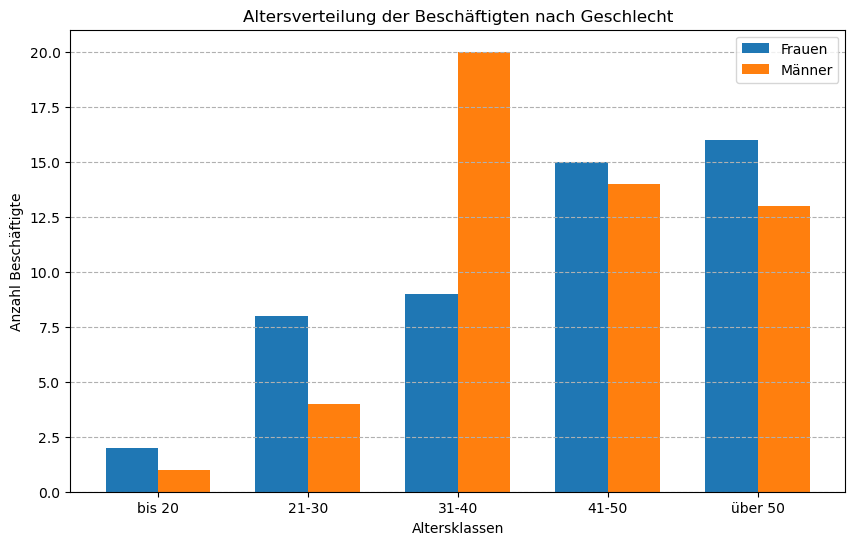

In [101]:
## d) Säulendiagramm mit Altersverteilung

import numpy as np
import matplotlib.pyplot as plt

# Altersklassen definieren
klassen = ['bis 20', '21-30', '31-40', '41-50', 'über 50']

data['Altersklasse'] = pd.cut(
    data['Alter'],
    bins=[0, 20, 30, 40, 50, 200],
    labels=klassen,
)

# Häufigkeiten getrennt nach Geschlecht bestimmen
frauen = data[data['Anrede'] == 'Frau']['Altersklasse'].value_counts().reindex(klassen, fill_value=0)
maenner = data[data['Anrede'] == 'Herr']['Altersklasse'].value_counts().reindex(klassen, fill_value=0)

# Positionen für die Balken
x = np.arange(len(klassen))
breite = 0.35

# Diagramm zeichnen
plt.figure(figsize=(10, 6))
plt.bar(x - breite/2, frauen, width=breite, label='Frauen')
plt.bar(x + breite/2, maenner, width=breite, label='Männer')

plt.xticks(x, klassen)
plt.xlabel('Altersklassen')
plt.ylabel('Anzahl Beschäftigte')
plt.title('Altersverteilung der Beschäftigten nach Geschlecht')
plt.legend()
plt.grid(axis='y', linestyle='--')

plt.show()


## e) Kreis-/Tortendiagramm der Altersverteilung
Stellen Sie die Altersverteilung der männlichen Beschäftigten und der weiblichen Beschäftigten in je einem Kreisdiagramm („Tortendiagramm“) dar. <br>
Die Kreissektoren sind mit den zugehörigen Prozentzahlen zu beschriften. 

***Beispiellösung:***
[Tortendiagramm der weiblichen Beschäftigten](https://drive.google.com/uc?id=17Z5Z8OgKw3DE4U_vD3axd7vhkkkD-N9m)

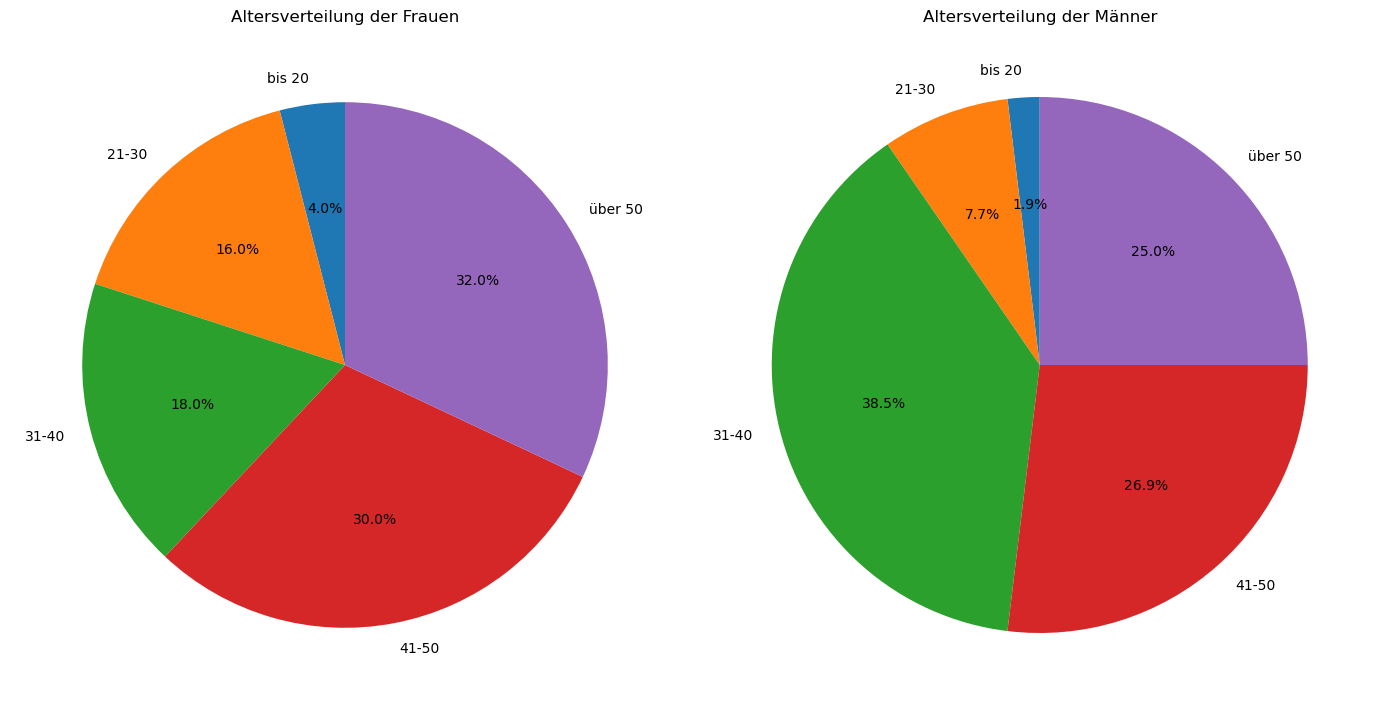

Anzahl Männer: 52
Anzahl Frauen: 50


In [102]:
## e) Kreis-/Tortendiagramm der Altersverteilung

import matplotlib.pyplot as plt

# Reihenfolge der Altersklassen festlegen
klassen = ['bis 20', '21-30', '31-40', '41-50', 'über 50']
anzahl_maenner = (data['Anrede'] == 'Herr').sum()
anzahl_frauen = (data['Anrede'] == 'Frau').sum()
# Häufigkeiten getrennt nach Geschlecht
frauen = data[data['Anrede'] == 'Frau']['Altersklasse'].value_counts().reindex(klassen, fill_value=0)
maenner = data[data['Anrede'] == 'Herr']['Altersklasse'].value_counts().reindex(klassen, fill_value=0)

# Zwei Kreisdiagramme nebeneinander
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].pie(
    frauen,
    labels=klassen,
    autopct='%1.1f%%',
    startangle=90,
    radius=(50/52)**0.5 
)
ax[0].set_title('Altersverteilung der Frauen')

ax[1].pie(
    maenner,
    labels=klassen,
    autopct='%1.1f%%',
    startangle=90,
    radius=1
)
ax[1].set_title('Altersverteilung der Männer')

plt.tight_layout()
plt.show()

print("Anzahl Männer:", anzahl_maenner)
print("Anzahl Frauen:", anzahl_frauen)


## f) Kennzahlen
Berechnen Sie **Mittelwert**, **empirische Varianz**, **empirische Standardabweichung**, **Median** und **Spannweite** der Alterszahlen: 
- für alle Beschäftigen und
- getrennt für Männer und Frauen.

***Tipp:*** Bitte auf max. 4 Nachkommastellen runden! <br>
***Beispiellösung:***
[Übersicht der Kennzahlen](https://drive.google.com/uc?id=1adhKBVlds5OlO-9B5CClT2ybPolv5wVW)

In [103]:
## f) Kennzahlen

def kennzahlen_berechnen(serie):
    return {
        'Mittelwert': round(serie.mean(), 4),
        'Varianz': round(serie.var(ddof=1), 4),
        'Std.-Abw.': round(serie.std(ddof=1), 4),
        'Median': round(serie.median(), 4),
        'Spannweite': round(serie.max() - serie.min(), 4)
    }

kennzahlen = pd.DataFrame({
    'gesamt': kennzahlen_berechnen(data['Alter']),
    'Frauen': kennzahlen_berechnen(data[data['Anrede'] == 'Frau']['Alter']),
    'Männer': kennzahlen_berechnen(data[data['Anrede'] == 'Herr']['Alter'])
})

display(kennzahlen)


,gesamt,Frauen,Männer
Mittelwert,43.3333,43.5400,43.1346
Varianz,147.2541,165.9678,132.0796
Std.-Abw.,12.1348,12.8828,11.4926
Median,42.5000,44.0000,42.0000
Spannweite,45.0000,45.0000,45.0000
